## Zero-Order Model - Baseline Model - Predicts Mean CGM Value

In [1]:
!python -m ensurepip --upgrade
!pip install -r ../requirements.txt

Looking in links: c:\Users\msbdj\AppData\Local\Temp\tmp1wliqtc5


## 30 Minute Prediction Horizon

Using subject id: 540
Total samples: 14842, train: 11873, test: 2969, n_predictions: 6
Zero-order hold baseline evaluation on test data (flattened across horizon):
  Samples (windows): 2963
  Horizon steps: 6
  MSE: 387.168
  RMSE: 19.677
  MAE: 13.182
  MARE (overall, %): 9.159


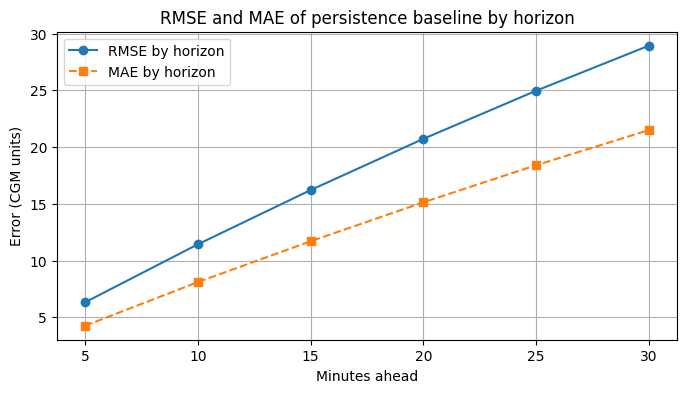

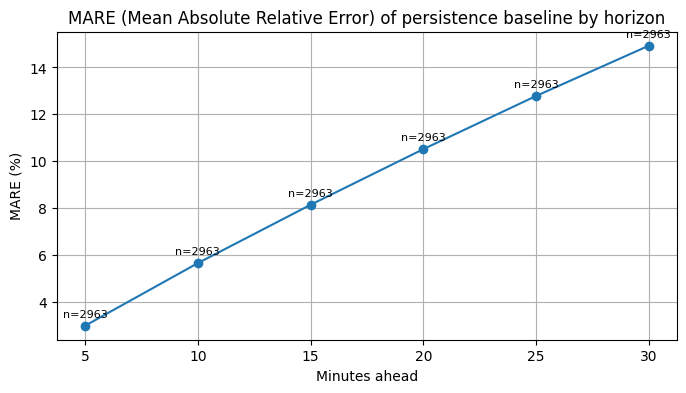

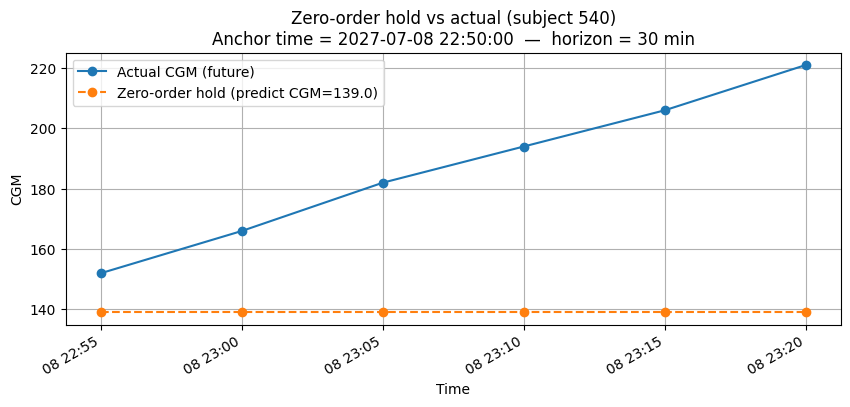

,anchor_time,last_cgm,actual_future_first,predicted_const
0,2027-07-03 18:00:00,238.0,240.0,238.0
1,2027-07-03 18:05:00,240.0,242.0,240.0
2,2027-07-03 18:10:00,242.0,243.0,242.0
3,2027-07-03 18:15:00,243.0,243.0,243.0
4,2027-07-03 18:20:00,243.0,244.0,243.0


In [3]:
# Zero-order hold (persistence) baseline for CGM
# With added per-horizon RMSE and MARE (mean absolute relative error) metrics & plots

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------- configuration --------
DATA_PATH = "../data/OhioT1DM.csv"
PRED_HORIZ_MIN = 30        # prediction horizon in minutes (e.g., 30-min)
STEP_MIN = 5               # sampling interval in minutes (assumed)
TEST_FRACTION = 0.2        # time-based test split fraction
SUBJECT_TO_PLOT = None     # None -> will pick first subject automatically
RNG = 42
# -------------------------------

# load and clean
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['id', 'date']).reset_index(drop=True)

# drop rows without CGM (can't use those for persistence)
df = df.dropna(subset=['CGM']).reset_index(drop=True)

# choose a subject (id)
subject_ids = df['id'].unique()
if SUBJECT_TO_PLOT is None:
    subject_id = subject_ids[0]
else:
    subject_id = SUBJECT_TO_PLOT
print("Using subject id:", subject_id)

sub = df[df['id'] == subject_id].copy().reset_index(drop=True)

# prediction horizon in number of samples
n_predictions = PRED_HORIZ_MIN // STEP_MIN

# time-based train/test split (use earliest 80% as train, last 20% as test)
n_total = len(sub)
split_idx = int((1 - TEST_FRACTION) * n_total)

train_df = sub.iloc[:split_idx].reset_index(drop=True)
test_df = sub.iloc[split_idx:].reset_index(drop=True)

print(f"Total samples: {n_total}, train: {len(train_df)}, test: {len(test_df)}, n_predictions: {n_predictions}")

# Build test samples for evaluation:
X_last = []      # scalar last CGM at anchor time i
Y_future = []    # vector of length n_predictions (actual future values)
times_future = []  # times corresponding to the future values (for optional plotting alignment)

for i in range(len(test_df) - n_predictions):
    last_cgm = test_df.loc[i, 'CGM']
    future_slice = test_df.loc[i + 1: i + n_predictions, 'CGM'].values
    future_times = test_df.loc[i + 1: i + n_predictions, 'date'].values
    if len(future_slice) == n_predictions:
        X_last.append(last_cgm)
        Y_future.append(future_slice)
        times_future.append(future_times)

X_last = np.array(X_last)                     # shape (N_samples,)
Y_future = np.array(Y_future)                 # shape (N_samples, n_predictions)
times_future = np.array(times_future)         # shape (N_samples, n_predictions) dtype datetime64

if Y_future.size == 0:
    raise ValueError("No valid test windows found. Check test split or n_predictions.")

# Zero-order hold prediction: repeat last observed CGM across horizon
Y_pred = np.repeat(X_last[:, None], n_predictions, axis=1)  # shape (N_samples, n_predictions)

# Flatten for overall metrics (compare every predicted future point)
y_true_flat = Y_future.ravel()
y_pred_flat = Y_pred.ravel()

mse = mean_squared_error(y_true_flat, y_pred_flat)
mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mse)

# MARE (mean absolute relative error) overall: avoid divide-by-zero by masking zeros
eps = 1e-8
mask_nonzero = (y_true_flat != 0)
if mask_nonzero.sum() == 0:
    overall_mare = np.nan
else:
    overall_mare = np.mean(np.abs((y_true_flat[mask_nonzero] - y_pred_flat[mask_nonzero]) / y_true_flat[mask_nonzero])) * 100.0

print(f"Zero-order hold baseline evaluation on test data (flattened across horizon):")
print(f"  Samples (windows): {Y_future.shape[0]}")
print(f"  Horizon steps: {n_predictions}")
print(f"  MSE: {mse:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"  MAE: {mae:.3f}")
print(f"  MARE (overall, %): {overall_mare:.3f}")

# --- Per-horizon metrics (for each step ahead: +5, +10, ... minutes) ---
# MSE per step (axis=0), then RMSE
mse_per_step = np.mean((Y_future - Y_pred)**2, axis=0)    # length n_predictions
rmse_per_step = np.sqrt(mse_per_step)

# MAE per step
mae_per_step = np.mean(np.abs(Y_future - Y_pred), axis=0)

# MARE per step (in percent). Handle zeros by using NaN and computing nanmean for that step.
mare_per_step = []
count_nonzero_per_step = []
for step in range(n_predictions):
    y_t = Y_future[:, step]
    y_p = Y_pred[:, step]
    nz_mask = (y_t != 0)
    count_nonzero_per_step.append(int(nz_mask.sum()))
    if nz_mask.sum() == 0:
        mare_per_step.append(np.nan)
    else:
        mare_val = np.mean(np.abs((y_t[nz_mask] - y_p[nz_mask]) / y_t[nz_mask])) * 100.0
        mare_per_step.append(mare_val)
mare_per_step = np.array(mare_per_step)

# x positions in minutes ahead
steps = np.arange(1, n_predictions + 1) * STEP_MIN

# --- Plots ---
plt.figure(figsize=(8,4))
plt.plot(steps, rmse_per_step, marker='o', linestyle='-', label='RMSE by horizon')
plt.plot(steps, mae_per_step, marker='s', linestyle='--', label='MAE by horizon')
plt.xlabel('Minutes ahead')
plt.ylabel('Error (CGM units)')
plt.title('RMSE and MAE of persistence baseline by horizon')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(steps, mare_per_step, marker='o', linestyle='-')
for i, cnt in enumerate(count_nonzero_per_step):
    plt.annotate(f"n={cnt}", (steps[i], mare_per_step[i]), textcoords="offset points", xytext=(0,6), ha='center', fontsize=8)
plt.xlabel('Minutes ahead')
plt.ylabel('MARE (%)')
plt.title('MARE (Mean Absolute Relative Error) of persistence baseline by horizon')
plt.grid(True)
plt.show()

# --- Single window plot: actual vs zero-order hold prediction for one example anchor ---
example_idx = max(0, len(Y_future)//2)  # pick a middle window example
y_actual = Y_future[example_idx]         # length n_predictions
y_pred_single = Y_pred[example_idx]      # repeated scalar
t_future = pd.to_datetime(times_future[example_idx])  # convert to pandas datetimes

plt.figure(figsize=(10,4))
plt.plot(t_future, y_actual, marker='o', linestyle='-', label='Actual CGM (future)')
plt.plot(t_future, y_pred_single, marker='o', linestyle='--', label=f'Zero-order hold (predict CGM={X_last[example_idx]:.1f})')
plt.xlabel('Time')
plt.ylabel('CGM')
plt.title(f'Zero-order hold vs actual (subject {subject_id})\nAnchor time = {test_df.loc[example_idx, "date"]}  —  horizon = {PRED_HORIZ_MIN} min')
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

# Optionally: show a small table of first 5 examples (anchor_time, last_cgm, actual_future[0], ... )
display_df = []
for j in range(min(5, len(Y_future))):
    anchor_time = test_df.loc[j, 'date']
    display_df.append({
        "anchor_time": anchor_time,
        "last_cgm": X_last[j],
        "actual_future_first": Y_future[j, 0],
        "predicted_const": X_last[j]
    })
display(pd.DataFrame(display_df))


C:\Users\mohamesb\AppData\Local\Temp\ipykernel_13900\4025081194.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  median_interval = df.groupby("id").apply(med_int).dropna().median()


subjects total/train/test = 12/9/3
samples train/test = 124717/41779  (steps=3)
Test RMSE = 16.11 mg/dL, MAE = 10.96 mg/dL


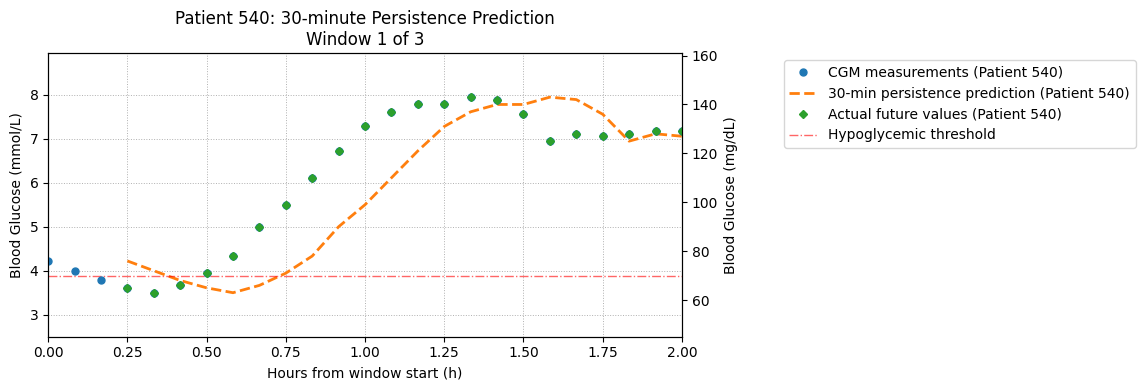

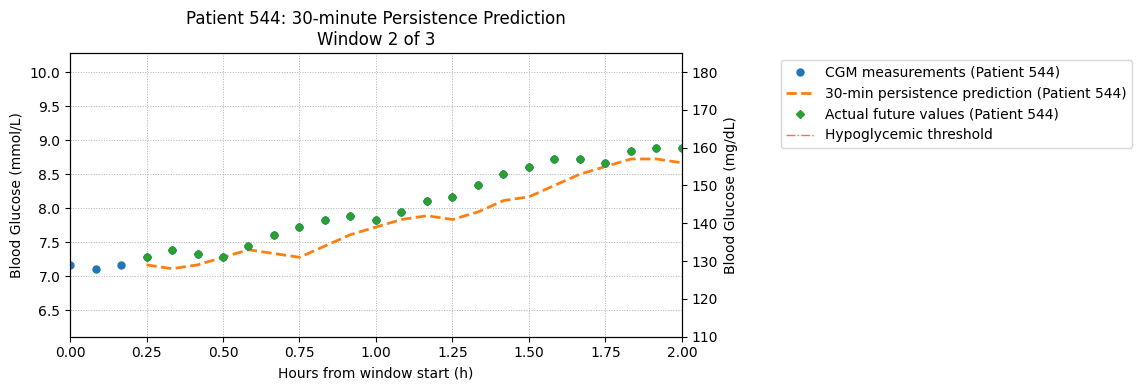

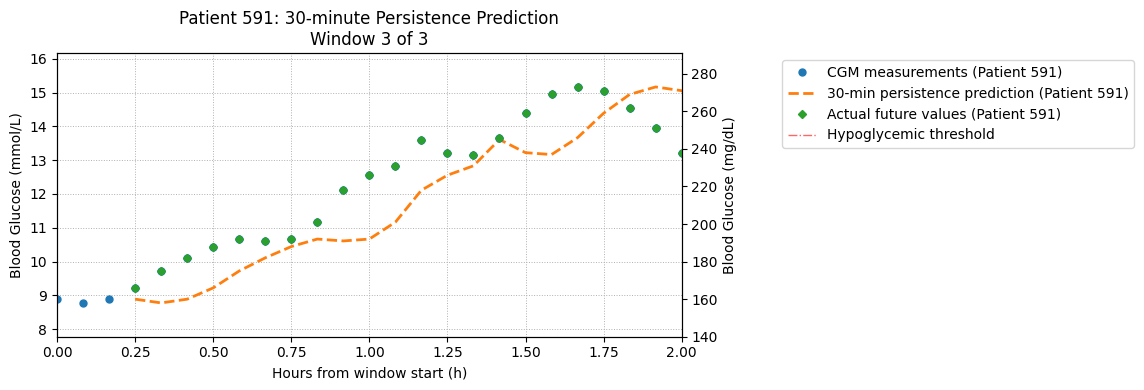

In [5]:
# Single notebook cell: minimal persistence (zero-order hold) baseline with 30-min delay
import os, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

random.seed(42); np.random.seed(42)
DATA = "../data/OhioT1DM.csv"   # adjust if needed
PH_MIN = 15                    # prediction horizon in minutes
TRAIN_FRACT = 0.8
WINDOW_HOURS = 2

if not os.path.exists(DATA):
    raise FileNotFoundError(f"File not found: {DATA}")

df = pd.read_csv(DATA, parse_dates=["date"]).sort_values(["id","date"]).reset_index(drop=True)
df = df.dropna(subset=["CGM"]).copy()
df["CGM"] = pd.to_numeric(df["CGM"], errors="coerce")

# get median sampling interval (minutes)
def med_int(g): 
    d = g["date"].diff().dt.total_seconds().dropna()/60.0
    return d.median() if len(d)>0 else np.nan
median_interval = df.groupby("id").apply(med_int).dropna().median()
if np.isnan(median_interval): raise RuntimeError("Cannot infer sampling interval.")
steps = max(1, int(round(PH_MIN/median_interval)))

# build supervised rows: target = CGM at t + steps (per subject)
rows = []
for sid, g in df.groupby("id"):
    g = g.reset_index(drop=True)
    if len(g) <= steps: continue
    g["target_CGM"] = g["CGM"].shift(-steps)
    g["pred_time"] = g["date"] + pd.Timedelta(minutes=PH_MIN)   # when the persistence prediction actually applies
    rows.append(g.loc[~g["target_CGM"].isna(), ["id","date","CGM","pred_time","target_CGM"]])
data = pd.concat(rows).reset_index(drop=True)
if data.empty: raise RuntimeError("No supervised samples found.")

# subject-level split (no leakage)
subjects = sorted(data["id"].unique()); random.shuffle(subjects)
ntrain = int(len(subjects)*TRAIN_FRACT)
train_s = set(subjects[:ntrain]); test_s = set(subjects[ntrain:])
train = data[data["id"].isin(train_s)].reset_index(drop=True)
test  = data[data["id"].isin(test_s)].reset_index(drop=True)
print(f"subjects total/train/test = {len(subjects)}/{len(train_s)}/{len(test_s)}")
print(f"samples train/test = {len(train)}/{len(test)}  (steps={steps})")

# persistence prediction: prediction at pred_time equals CGM at current time
y_true = test["target_CGM"].values
y_pred = test["CGM"].values
rmse_mgdl = np.sqrt(mean_squared_error(y_true, y_pred))
mae_mgdl  = mean_absolute_error(y_true, y_pred)
print(f"Test RMSE = {rmse_mgdl:.2f} mg/dL, MAE = {mae_mgdl:.2f} mg/dL")

# convert to mmol/L for plotting (1 mmol/L = 18 mg/dL)
test["target_mmol"] = test["target_CGM"]/18.0
test["pred_mmol"]   = test["CGM"]/18.0
test["actual_mmol"] = test["CGM"]/18.0  # same numeric values, plotted at different times

# plotting: up to 3 windows from distinct test subjects
hyp_mmol = 70.0/18.0
test_subjects = list(test["id"].unique())[:6]
count = 0
for sid in test_subjects:
    if count>=3: break
    sub = test[test["id"]==sid].sort_values("date").reset_index(drop=True)
    if len(sub) < 5: continue
    start = sub["date"].iloc[0]
    # include rows whose original time or pred_time falls within 0..WINDOW_HOURS from start
    mask = ((sub["date"] - start).dt.total_seconds() <= WINDOW_HOURS*3600) | \
           ((sub["pred_time"] - start).dt.total_seconds() <= WINDOW_HOURS*3600)
    win = sub.loc[mask].copy()
    if win.empty: continue

    x_actual = (win["date"] - start).dt.total_seconds()/3600.0
    x_pred   = (win["pred_time"] - start).dt.total_seconds()/3600.0

    fig, ax1 = plt.subplots(figsize=(12,4))  # Wider figure to accommodate legend
    
    # Plot on primary axis
    l1 = ax1.plot(x_actual, win["actual_mmol"], 'o', markersize=5, 
             label=f"CGM measurements (Patient {sid})", zorder=3)
    order = np.argsort(x_pred)
    l2 = ax1.plot(x_pred.values[order], win["pred_mmol"].values[order], 
             linestyle="--", linewidth=2, 
             label=f"30-min persistence prediction (Patient {sid})", zorder=2)
    l3 = ax1.plot(x_pred, win["target_mmol"], 'D', markersize=4, 
             label=f"Actual future values (Patient {sid})", zorder=4)
    
    ax1.set_xlim(0, WINDOW_HOURS)
    ax1.set_ylim(max(0, min(win["actual_mmol"].min(), win["pred_mmol"].min(), win["target_mmol"].min())-1),
             max(win["actual_mmol"].max(), win["pred_mmol"].max(), win["target_mmol"].max())+1)
    ax1.set_xlabel("Hours from window start (h)")
    ax1.set_ylabel("Blood Glucose (mmol/L)")
    ax1.grid(linestyle=':', linewidth=0.7)
    
    # Second y-axis in mg/dL
    ax2 = ax1.twinx()
    ax2.set_ylim(ax1.get_ylim()[0]*18, ax1.get_ylim()[1]*18)
    ax2.set_ylabel("Blood Glucose (mg/dL)")
    
    # Add hypoglycemia threshold line
    l4 = ax1.axhline(hyp_mmol, linestyle='-.', linewidth=1, alpha=0.6, color='red', 
                     label='Hypoglycemic threshold')
    
    # Combine legends from both axes
    lines = l1 + l2 + l3 + [l4]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, bbox_to_anchor=(1.15, 1))
    
    plt.title(f"Patient {sid}: 30-minute Persistence Prediction\nWindow {count+1} of 3")
    plt.tight_layout()
    plt.show()
    count += 1

In [6]:
# --- Additional evaluation cell ---
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from error_grids import zone_accuracy   # same function used in your metric classes

# thresholds for glycemia detection
HYPO_T = 70.0
HYPER_T = 180.0
LABELS = {0: "Hypoglycemia (<70)", 1: "Euglycemia (70-180)", 2: "Hyperglycemia (>180)"}

# get arrays from the test DataFrame created earlier in the notebook
y_true = test["target_CGM"].values
y_pred = test["CGM"].values

# filter invalid/NaN pairs (safe-guard)
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = np.asarray(y_true)[mask]
y_pred = np.asarray(y_pred)[mask]

if len(y_true) == 0:
    raise RuntimeError("No valid (finite) prediction/target pairs found for evaluation.")

# 1) RMSE and MAE (mg/dL and mmol/L)
rmse_mgdl = np.sqrt(mean_squared_error(y_true, y_pred))
mae_mgdl  = mean_absolute_error(y_true, y_pred)
# convert to mmol/L (1 mmol/L = 18 mg/dL)
rmse_mmol = rmse_mgdl / 18.0
mae_mmol  = mae_mgdl  / 18.0

print("=== Glucose error summary ===")
print(f"RMSE = {rmse_mgdl:.2f} mg/dL  ({rmse_mmol:.3f} mmol/L)")
print(f"MAE  = {mae_mgdl:.2f} mg/dL  ({mae_mmol:.3f} mmol/L)")
print()

# 2) Clarke and Parkes error grids (zone accuracies)
# zone_accuracy returns fractions per zone (the order depends on the library: typically [A, B, C, D, E])
clarke_vals = zone_accuracy(y_true, y_pred, 'clarke')
parkes_vals = zone_accuracy(y_true, y_pred, 'parkes')

# Format to percent strings
clarke_pct = ["{:.1f}%".format(v*100) for v in clarke_vals]
parkes_pct = ["{:.1f}%".format(v*100) for v in parkes_vals]

# Try to label zones A..E (works with common error_grid outputs)
zone_names = ["A", "B", "C", "D", "E"]
clarke_df = pd.DataFrame({"Zone": zone_names, "Clarke (%)": clarke_pct, "Clarke (fraction)": clarke_vals})
parkes_df = pd.DataFrame({"Zone": zone_names, "Parkes (%)": parkes_pct, "Parkes (fraction)": parkes_vals})

print("=== Clarke Error Grid (zone accuracies) ===")
print(clarke_df.to_string(index=False))
print()
print("=== Parkes Error Grid (zone accuracies) ===")
print(parkes_df.to_string(index=False))
print()

# 3) Glycemia detection confusion matrix (counts and per-true-class percentages)
def glycemia_category(vals):
    """Map mg/dL values to 0:hypo,1:eu,2:hyper"""
    vals = np.array(vals)
    cats = np.zeros_like(vals, dtype=int)
    cats[vals >= HYPER_T] = 2
    cats[(vals >= HYPO_T) & (vals < HYPER_T)] = 1
    cats[vals < HYPO_T] = 0
    return cats

true_cat = glycemia_category(y_true)
pred_cat = glycemia_category(y_pred)

# counts matrix: rows = true, cols = predicted
cm_counts = pd.crosstab(pd.Series(true_cat, name="True"),
                        pd.Series(pred_cat, name="Pred"),
                        rownames=["True"], colnames=["Pred"]).reindex(index=[0,1,2], columns=[0,1,2], fill_value=0)

# percentages per-true-class (i.e., normalize rows -> among true class, how often predicted as each class)
row_sums = cm_counts.sum(axis=1).replace(0, np.nan)  # avoid division by zero
cm_percent = cm_counts.div(row_sums, axis=0)

# label rows and columns
idx = [LABELS[i] for i in [0,1,2]]
cm_counts.index = cm_counts.columns = idx
cm_percent.index = cm_percent.columns = idx

print("=== Glycemia detection confusion matrix (counts) ===")
display(cm_counts)   # if in Jupyter, will render nicely; otherwise prints below
print()
print("=== Glycemia detection confusion matrix (percentages by true class) ===")
display((cm_percent * 100).round(2))   # show as percent with 2 decimals
print()

# also return raw numpy matrix if needed
cm_counts_np = cm_counts.values
cm_percent_np = cm_percent.fillna(0).values   # NaN -> 0 for safe numeric usage

# Summary metrics per-class (recall / sensitivity)
recalls = np.diag(cm_counts) / cm_counts.sum(axis=1)
recalls_df = pd.DataFrame({"Class": idx, "Recall (sensitivity)": recalls})
print("=== Per-class recall (sensitivity) ===")
print(recalls_df.to_string(index=False))

# Save results into a dict to be used programmatically later in the notebook
eval_results = {
    "rmse_mgdl": rmse_mgdl,
    "mae_mgdl": mae_mgdl,
    "rmse_mmol": rmse_mmol,
    "mae_mmol": mae_mmol,
    "clarke_zone_fractions": clarke_vals,
    "parkes_zone_fractions": parkes_vals,
    "glycemia_counts": cm_counts_np,
    "glycemia_pct_by_true": cm_percent_np,
    "glycemia_counts_df": cm_counts,
    "glycemia_pct_df": cm_percent
}

# Optionally: print a short programmatic summary
print()
print("Evaluation results saved to `eval_results` dict (keys: {})".format(", ".join(eval_results.keys())))


=== Glucose error summary ===
RMSE = 16.11 mg/dL  (0.895 mmol/L)
MAE  = 10.96 mg/dL  (0.609 mmol/L)

=== Clarke Error Grid (zone accuracies) ===
Zone Clarke (%)  Clarke (fraction)
   A      92.7%           0.927236
   B       6.6%           0.066277
   C       0.0%           0.000311
   D       0.6%           0.005816
   E       0.0%           0.000359

=== Parkes Error Grid (zone accuracies) ===
Zone Parkes (%)  Parkes (fraction)
   A      93.5%           0.934513
   B       6.4%           0.063549
   C       0.2%           0.001675
   D       0.0%           0.000263
   E       0.0%           0.000000

=== Glycemia detection confusion matrix (counts) ===


,Hypoglycemia (<70),Euglycemia (70-180),Hyperglycemia (>180)
Hypoglycemia (<70),1069,528,5
Euglycemia (70-180),524,26056,1222
Hyperglycemia (>180),10,1223,11142



=== Glycemia detection confusion matrix (percentages by true class) ===


,Hypoglycemia (<70),Euglycemia (70-180),Hyperglycemia (>180)
Hypoglycemia (<70),66.73,32.96,0.31
Euglycemia (70-180),1.88,93.72,4.40
Hyperglycemia (>180),0.08,9.88,90.04



=== Per-class recall (sensitivity) ===
               Class  Recall (sensitivity)
  Hypoglycemia (<70)              0.667291
 Euglycemia (70-180)              0.937199
Hyperglycemia (>180)              0.900364

Evaluation results saved to `eval_results` dict (keys: rmse_mgdl, mae_mgdl, rmse_mmol, mae_mmol, clarke_zone_fractions, parkes_zone_fractions, glycemia_counts, glycemia_pct_by_true, glycemia_counts_df, glycemia_pct_df)


Samples = 41779
RMSE (mg/dL) = 16.114 ; MAE (mg/dL) = 10.960

Installing GluPredKit (for exact Clarke/Parkes zones) ...
GluPredKit not available — will use robust fallback classifiers for zone assignment.
Clarke zone breakdown (zone: (count, %)):
  A: 38890 (93.09%)
  B: 2874 (6.88%)
  C: 5 (0.01%)
  D: 10 (0.02%)

Parkes zone breakdown (zone: (count, %)):
  A: 38803 (92.88%)
  B: 2413 (5.78%)
  C: 450 (1.08%)
  D: 15 (0.04%)
  E: 98 (0.23%)


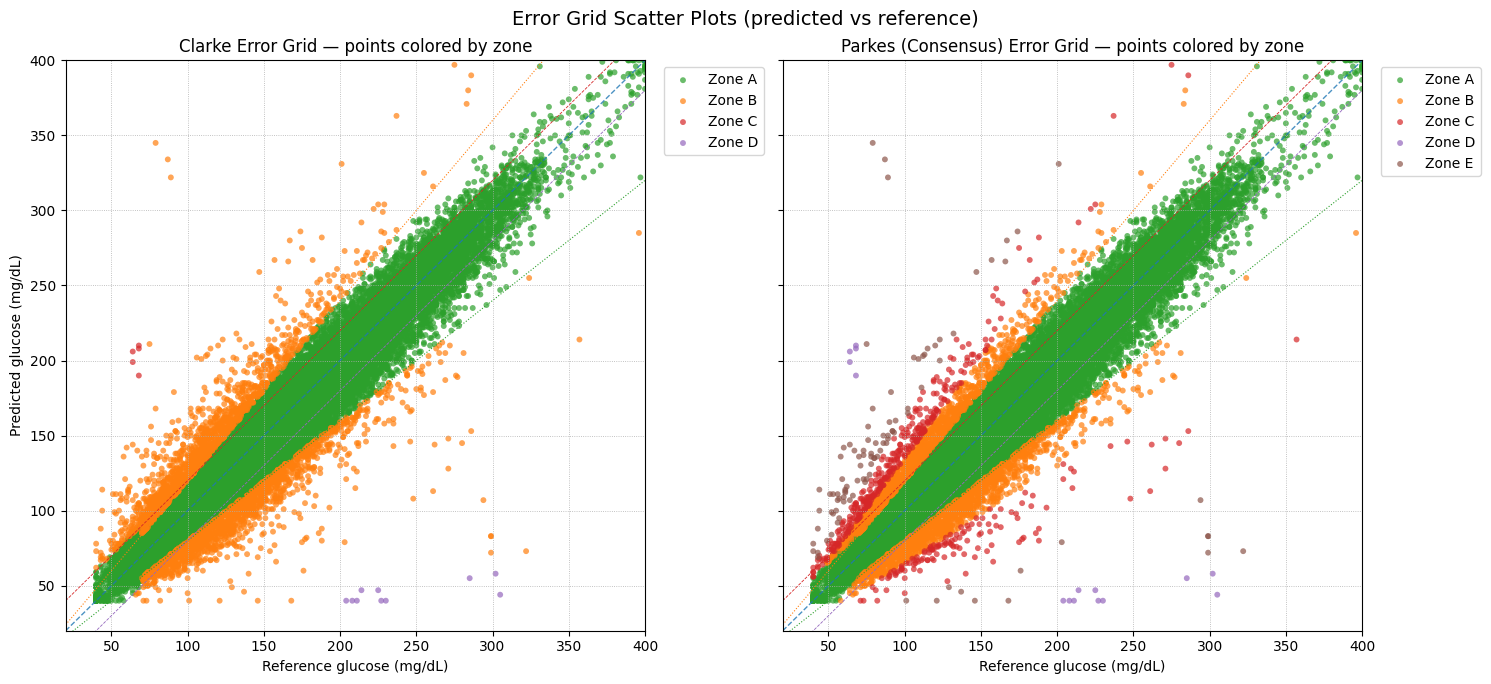

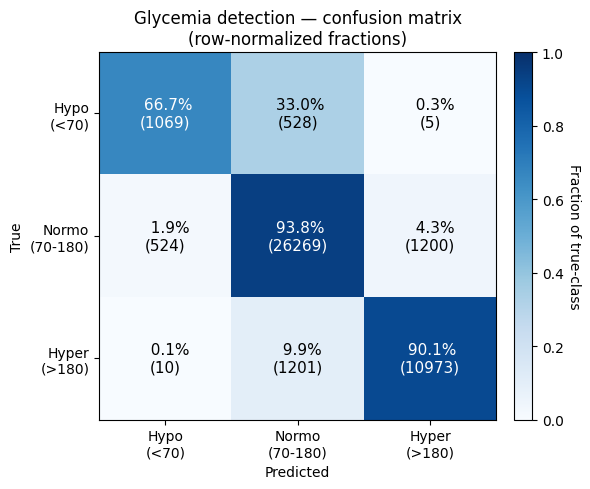


Plotting complete. Notes:
- Error-grid points are colored by zone labels (exact zones if GluPredKit available; otherwise heuristic fallback).
- Clarke plot shows ±20% and ±20 mg/dL guide lines (canonical visual guides).
- Confusion matrix is row-normalized (each row shows fraction of that true-class predicted as each label).


In [9]:
# --- Final plotting cell: actual Clarke & Parkes error-grid scatter plots + single confusion matrix ---
import sys, subprocess
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter

# ---------- 1) Obtain y_true / y_pred ----------
# Try common sources (in order): explicit y_true/y_pred, eval_results dict, 'test' DataFrame (from earlier cell)
if 'y_true' in globals() and 'y_pred' in globals():
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
elif 'eval_results' in globals() and isinstance(eval_results, dict) and eval_results.get("glycemia_counts_df") is not None:
    # eval_results doesn't directly store y arrays, so prefer 'test' if available; otherwise error
    if 'test' in globals():
        y_true = test["target_CGM"].values
        y_pred = test["CGM"].values
    else:
        raise RuntimeError("No y_true/y_pred found in globals. Run the evaluation cell that computes them.")
elif 'test' in globals():
    y_true = test["target_CGM"].values
    y_pred = test["CGM"].values
else:
    raise RuntimeError("Couldn't find y_true/y_pred or `test` DataFrame in this notebook. Run the earlier cells first.")

# filter finite
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]
if y_true.size == 0:
    raise RuntimeError("No valid finite pairs of y_true/y_pred available for plotting.")

# numeric summaries
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
print(f"Samples = {len(y_true)}")
print(f"RMSE (mg/dL) = {rmse:.3f} ; MAE (mg/dL) = {mae:.3f}\n")

# ---------- 2) Try to use GluPredKit for exact zone assignment (recommended) ----------
use_glupredkit = True
clarke_zone_labels = None
parkes_zone_labels = None

try:
    import glupredkit
    try:
        # common paths in different versions
        from glupredkit.evaluation.metrics import clarke_error_grid, parkes_error_grid
    except Exception:
        try:
            from glupredkit.metrics import clarke_error_grid, parkes_error_grid
        except Exception:
            raise ImportError("GluPredKit import path not found")
except Exception:
    # attempt to pip install GluPredKit (best-effort)
    try:
        print("Installing GluPredKit (for exact Clarke/Parkes zones) ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "GluPredKit"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        import glupredkit
        try:
            from glupredkit.evaluation.metrics import clarke_error_grid, parkes_error_grid
        except Exception:
            from glupredkit.metrics import clarke_error_grid, parkes_error_grid
    except Exception:
        use_glupredkit = False
        print("GluPredKit not available — will use robust fallback classifiers for zone assignment.")

# If available, try to produce per-sample zone labels (many implementations return arrays/lists of zone labels)
if use_glupredkit:
    try:
        cz_out = clarke_error_grid(y_true, y_pred)  # signature varies by version
        # Normalize output to a vector of zone labels if possible
        if isinstance(cz_out, dict):
            # older versions sometimes return dict of counts; fall back to per-point if available
            clarke_zone_labels = None
        else:
            cz = np.asarray(cz_out)
            if cz.size == y_true.size:
                clarke_zone_labels = cz.astype(str)
    except Exception:
        clarke_zone_labels = None

    try:
        pz_out = parkes_error_grid(y_true, y_pred)
        if isinstance(pz_out, dict):
            parkes_zone_labels = None
        else:
            pz = np.asarray(pz_out)
            if pz.size == y_true.size:
                parkes_zone_labels = pz.astype(str)
    except Exception:
        parkes_zone_labels = None

# ---------- 3) Fallback zone classifiers (compact, diagnostic heuristics) ----------
def clarke_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred):
        return None
    # Zone A
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20):
        return 'A'
    # Zone E very extreme opposite
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330):
        return 'E'
    # wrong-treatment / missed-detection approximations
    if ref < 70 and pred >= 180:
        return 'C'
    if ref >= 180 and pred < 70:
        return 'D'
    return 'B'

def parkes_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred):
        return None
    err = pred - ref
    rel_err = abs(err) / max(ref, 1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2):
        return 'A'
    if rel_err <= 0.35:
        return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70):
        return 'D'
    if rel_err > 0.6:
        return 'E'
    return 'C'

if clarke_zone_labels is None:
    clarke_zone_labels = np.array([clarke_zone_for_point(r, p) for r,p in zip(y_true, y_pred)], dtype=object)
if parkes_zone_labels is None:
    parkes_zone_labels = np.array([parkes_zone_for_point(r, p) for r,p in zip(y_true, y_pred)], dtype=object)

# Compute zone counts/percent for printing
def zones_to_counts(zlabels):
    c = Counter([z for z in zlabels if z is not None])
    total = len([z for z in zlabels if z is not None])
    out = {k:(int(v), 100.0*int(v)/total) for k,v in c.items()}
    return out

print("Clarke zone breakdown (zone: (count, %)):")
for z,(ct,pct) in sorted(zones_to_counts(clarke_zone_labels).items()):
    print(f"  {z}: {ct} ({pct:.2f}%)")
print("\nParkes zone breakdown (zone: (count, %)):")
for z,(ct,pct) in sorted(zones_to_counts(parkes_zone_labels).items()):
    print(f"  {z}: {ct} ({pct:.2f}%)")

# ---------- 4) Prepare plotting helpers ----------
zone_color_map = {'A':'#2ca02c', 'B':'#ff7f0e', 'C':'#d62728', 'D':'#9467bd', 'E':'#8c564b', None:'#7f7f7f'}
mn = max(0.0, min(np.nanmin(y_true), np.nanmin(y_pred), 20.0))
mx = max(np.nanmax(y_true), np.nanmax(y_pred), 400.0)
xs = np.linspace(mn, mx, 800)

# ---------- 5) Plot Clarke and Parkes error-grid style scatter plots ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)

# Clarke panel
ax = axes[0]
# identity line and canonical Clarke guidance
ax.plot(xs, xs, '--', linewidth=1.0, alpha=0.8)
ax.plot(xs, 1.2*xs, ':', linewidth=0.8)
ax.plot(xs, 0.8*xs, ':', linewidth=0.8)
ax.plot(xs, xs + 20.0, '--', linewidth=0.6)
ax.plot(xs, xs - 20.0, '--', linewidth=0.6)

# scatter colored by zone
unique_z = [z for z in np.unique(clarke_zone_labels) if z is not None]
for z in unique_z:
    idx = np.where(clarke_zone_labels == z)[0]
    ax.scatter(y_true[idx], y_pred[idx], s=18, alpha=0.7, label=f"Zone {z}", color=zone_color_map.get(z, '#7f7f7f'), edgecolors='none')

ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)
ax.set_xlabel("Reference glucose (mg/dL)")
ax.set_ylabel("Predicted glucose (mg/dL)")
ax.set_title("Clarke Error Grid — points colored by zone")
ax.grid(linestyle=':', linewidth=0.6)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# Parkes panel
ax = axes[1]
ax.plot(xs, xs, '--', linewidth=1.0, alpha=0.8)
# show the same ±20% and ±20 mg/dL guides for orientation (Parkes true polygons are more complex)
ax.plot(xs, 1.2*xs, ':', linewidth=0.8)
ax.plot(xs, 0.8*xs, ':', linewidth=0.8)
ax.plot(xs, xs + 20.0, '--', linewidth=0.6)
ax.plot(xs, xs - 20.0, '--', linewidth=0.6)

unique_z = [z for z in np.unique(parkes_zone_labels) if z is not None]
for z in unique_z:
    idx = np.where(parkes_zone_labels == z)[0]
    ax.scatter(y_true[idx], y_pred[idx], s=18, alpha=0.7, label=f"Zone {z}", color=zone_color_map.get(z, '#7f7f7f'), edgecolors='none')

ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)
ax.set_xlabel("Reference glucose (mg/dL)")
ax.set_title("Parkes (Consensus) Error Grid — points colored by zone")
ax.grid(linestyle=':', linewidth=0.6)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.suptitle("Error Grid Scatter Plots (predicted vs reference)", fontsize=14, y=0.97)
plt.tight_layout()
plt.show()

# ---------- 6) Single confusion matrix (row-normalized percentages) ----------
HYPO = 70
HYPER = 180

def glycemia_class(x, hypo=HYPO, hyper=HYPER):
    x = np.asarray(x)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < hypo] = 0
    cls[(x >= hypo) & (x <= hyper)] = 1
    cls[x > hyper] = 2
    return cls

def compute_glycemia_confusion(y_true, y_pred, hypo=HYPO, hyper=HYPER):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]; y_pred = y_pred[mask]
    counts = np.zeros((3,3), dtype=int)
    if y_true.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    tcls = glycemia_class(y_true, hypo, hyper)
    pcls = glycemia_class(y_pred, hypo, hyper)
    for t,p in zip(tcls, pcls):
        if 0 <= t <= 2 and 0 <= p <= 2:
            counts[t,p] += 1
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        s = counts[i].sum()
        if s>0:
            pct[i,:] = counts[i,:] / float(s)
    return counts, pct

counts, pct = compute_glycemia_confusion(y_true, y_pred, HYPO, HYPER)

# Plot heatmap: use row-normalized fractions (pct); annotate with "xx.x% (count)"
fig, ax = plt.subplots(1,1, figsize=(6,5))
im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap='Blues', interpolation='nearest', aspect='auto')
labels = ['Hypo\n(<70)', 'Normo\n(70-180)', 'Hyper\n(>180)']
ax.set_xticks(np.arange(3)); ax.set_yticks(np.arange(3))
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Glycemia detection — confusion matrix\n(row-normalized fractions)")

# annotations
for i in range(3):
    for j in range(3):
        c = counts[i,j]
        p = pct[i,j]
        if np.isnan(p):
            txt = "n/a\n(0)"
        else:
            txt = f"{p*100:5.1f}%\n({c})"
        # pick contrasting color based on background intensity
        bg = 0.0 if np.isnan(p) else p
        text_color = 'white' if bg > 0.6 else 'black'
        ax.text(j, i, txt, ha='center', va='center', color=text_color, fontsize=11)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('Fraction of true-class', rotation=270, labelpad=12)

plt.tight_layout()
plt.show()

# ---------- Finished ----------
print("\nPlotting complete. Notes:")
print("- Error-grid points are colored by zone labels (exact zones if GluPredKit available; otherwise heuristic fallback).")
print("- Clarke plot shows ±20% and ±20 mg/dL guide lines (canonical visual guides).")
print("- Confusion matrix is row-normalized (each row shows fraction of that true-class predicted as each label).")
